# Calculate Summary Statistics for a DataFrame or Series

Many datasets are large, and it can be helpful to get a summary of information in them. Let's load a dataset and examine the first few rows:

In [1]:
import pandas as pd

df = pd.read_csv("./data/iris.csv",names=['Sepal_Length','Sepal_Width','Petal_Length','Petal_Width','Species'])
df.head()


,Sepal_Length,Sepal_Width,Petal_Length,Petal_Width,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


Let's get a summary description of this dataset.

In [2]:
df.describe()

,Sepal_Length,Sepal_Width,Petal_Length,Petal_Width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


# Select a Series from a DataFrame

In [3]:
df2 = df["Sepal_Width"]
df2

0      3.5
1      3.0
2      3.2
3      3.1
4      3.6
      ... 
145    3.0
146    2.5
147    3.0
148    3.4
149    3.0
Name: Sepal_Width, Length: 150, dtype: float64

# Subset a DataFrame by Selecting One or More Columns

In [4]:
df2 = df[["Sepal_Width","Petal_Length"]]

df2

,Sepal_Width,Petal_Length
0,3.5,1.4
1,3.0,1.4
2,3.2,1.3
3,3.1,1.5
4,3.6,1.4
...,...,...
145,3.0,5.2
146,2.5,5.0
147,3.0,5.2
148,3.4,5.4


# Subset the Columns of a DataFrame Based on Data Types

In [5]:
df2 = df.select_dtypes(include="number")
df2.head()

,Sepal_Length,Sepal_Width,Petal_Length,Petal_Width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


# Working with value_counts in a Series

In [6]:
df["Species"].value_counts()

Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64

# Series and Groupby

In [7]:
sp_group = df.groupby("Species")

In [8]:
type(sp_group)

pandas.core.groupby.generic.DataFrameGroupBy

In [9]:
sp_group.first()

,Sepal_Length,Sepal_Width,Petal_Length,Petal_Width
Species,,,,
Iris-setosa,5.1,3.5,1.4,0.2
Iris-versicolor,7.0,3.2,4.7,1.4
Iris-virginica,6.3,3.3,6.0,2.5


Now that we have all the properties grouped by department, we might want to see the properties in just one of the departments. We can use the get_group method to do that. If we just wanted to see the properties in "Santander", for example, the code would look like this:

In [10]:
sp_group = df.groupby("Species")
sp_group.get_group("Iris-setosa")

,Sepal_Length,Sepal_Width,Petal_Length,Petal_Width,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa
5,5.4,3.9,1.7,0.4,Iris-setosa
6,4.6,3.4,1.4,0.3,Iris-setosa
7,5.0,3.4,1.5,0.2,Iris-setosa
8,4.4,2.9,1.4,0.2,Iris-setosa
9,4.9,3.1,1.5,0.1,Iris-setosa


### Bin a column

In [11]:

# Create a new column 'sepal_size' based on sepal length
df["Sepal_Size"] = pd.cut(
    df["Sepal_Length"],
    bins=[0, 5.5, 6.5, float("inf")],  # define ranges
    labels=["Small", "Medium", "Large"]  # assign labels
)

df["Petal_Size"] = pd.cut(
    df["Petal_Length"],
    bins=[0, 1, 3, float("inf")],  # define ranges
    labels=["Small", "Medium", "Large"]  # assign labels
)


df

,Sepal_Length,Sepal_Width,Petal_Length,Petal_Width,Species,Sepal_Size,Petal_Size
0,5.1,3.5,1.4,0.2,Iris-setosa,Small,Medium
1,4.9,3.0,1.4,0.2,Iris-setosa,Small,Medium
2,4.7,3.2,1.3,0.2,Iris-setosa,Small,Medium
3,4.6,3.1,1.5,0.2,Iris-setosa,Small,Medium
4,5.0,3.6,1.4,0.2,Iris-setosa,Small,Medium
...,...,...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,Iris-virginica,Large,Large
146,6.3,2.5,5.0,1.9,Iris-virginica,Medium,Large
147,6.5,3.0,5.2,2.0,Iris-virginica,Medium,Large
148,6.2,3.4,5.4,2.3,Iris-virginica,Medium,Large


### Multiple Groupby

In [12]:
sp_group = df.groupby(['Species','Sepal_Size'])

sp_group.first()

/tmp/ipykernel_7829/4096778835.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sp_group = df.groupby(['Species','Sepal_Size'])


Sepal_Length  Sepal_Width  Petal_Length  \
Species         Sepal_Size                                            
Iris-setosa     Small                5.1          3.5           1.4   
                Medium               5.8          4.0           1.2   
                Large                NaN          NaN           NaN   
Iris-versicolor Small                5.5          2.3           4.0   
                Medium               6.4          3.2           4.5   
                Large                7.0          3.2           4.7   
Iris-virginica  Small                4.9          2.5           4.5   
                Medium               6.3          3.3           6.0   
                Large                7.1          3.0           5.9   

                            Petal_Width Petal_Size  
Species         Sepal_Size                          
Iris-setosa     Small               0.2     Medium  
                Medium              0.2     Medium  
                Large               NaN        NaN  
Iris-versicolor Small               1.3      Large  
                Medium              1.5      Large  
                Large               1.4      Large  
Iris-virginica  Small               1.7      Large  
                Medium              2.5      Large  
                Large               2.1      Large

Aggregation in Groups

In [13]:
sp_group = df.groupby("Species")["Sepal_Length"].mean()
sp_group

Species
Iris-setosa        5.006
Iris-versicolor    5.936
Iris-virginica     6.588
Name: Sepal_Length, dtype: float64

# Subset a DataFrame's Columns Based on the Column Data Types

In [14]:
df2 = df.select_dtypes(include="number")
df2.head()

,Sepal_Length,Sepal_Width,Petal_Length,Petal_Width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [15]:
df2 =df.select_dtypes(exclude="number")
df2.head()

,Species,Sepal_Size,Petal_Size
0,Iris-setosa,Small,Medium
1,Iris-setosa,Small,Medium
2,Iris-setosa,Small,Medium
3,Iris-setosa,Small,Medium
4,Iris-setosa,Small,Medium


# Subset a DataFrame's columns based on column names

In [16]:
drop_cols = [
    "Sepal_Length",
    "Sepal_Size"
]

keep_cols = ["Petal_Length", "Petal_Width"]

Next, we'll explore both approaches to subset mexico_city3. To retain columns based on keep_cols:

In [17]:
df2 = df[keep_cols]
df2

,Petal_Length,Petal_Width
0,1.4,0.2
1,1.4,0.2
2,1.3,0.2
3,1.5,0.2
4,1.4,0.2
...,...,...
145,5.2,2.3
146,5.0,1.9
147,5.2,2.0
148,5.4,2.3


To drop columns in drop_cols:

In [18]:
df2 = df.drop(columns=drop_cols)
df2

,Sepal_Width,Petal_Length,Petal_Width,Species,Petal_Size
0,3.5,1.4,0.2,Iris-setosa,Medium
1,3.0,1.4,0.2,Iris-setosa,Medium
2,3.2,1.3,0.2,Iris-setosa,Medium
3,3.1,1.5,0.2,Iris-setosa,Medium
4,3.6,1.4,0.2,Iris-setosa,Medium
...,...,...,...,...,...
145,3.0,5.2,2.3,Iris-virginica,Large
146,2.5,5.0,1.9,Iris-virginica,Large
147,3.0,5.2,2.0,Iris-virginica,Large
148,3.4,5.4,2.3,Iris-virginica,Large


## Pivot Tables
A pivot table allows you to quickly aggregate and summarize a DataFrame using an aggregation function. 

In [19]:
# Create a pivot table: mean petal length for each combination of sepal_size and target
pivot_table = pd.pivot_table(
    df,
    values="Petal_Length",
    index="Sepal_Size",    # rows
    columns="Petal_Size",      # columns
    aggfunc="mean"         # aggregation function
)

pivot_table

/tmp/ipykernel_7829/2938376022.py:2: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot_table = pd.pivot_table(


Petal_Size,Small,Medium,Large
Sepal_Size,,,
Small,1.0,1.506383,3.900000
Medium,NaN,1.466667,4.758621
Large,NaN,NaN,5.623333


# Subsetting with Masks

In [20]:
mask = df["Sepal_Length"] > 5
mask.head()

0     True
1    False
2    False
3    False
4    False
Name: Sepal_Length, dtype: bool

In [21]:
df[mask].shape,df.shape

((118, 7), (150, 7))

We can also create masks with multiple criteria using & for "and" and | for "or."

In [23]:
mask = (df["Sepal_Length"] > 5) & (df["Sepal_Size"] == "Medium")
df[mask].head()

,Sepal_Length,Sepal_Width,Petal_Length,Petal_Width,Species,Sepal_Size,Petal_Size
14,5.8,4.0,1.2,0.2,Iris-setosa,Medium,Medium
15,5.7,4.4,1.5,0.4,Iris-setosa,Medium,Medium
18,5.7,3.8,1.7,0.3,Iris-setosa,Medium,Medium
51,6.4,3.2,4.5,1.5,Iris-versicolor,Medium,Large
54,6.5,2.8,4.6,1.5,Iris-versicolor,Medium,Large


## Combine multiple categories in a Series

Categorical variables can be collapsed into a fewer number of categories. One approach is to retain the values of the most frequently observed values and collapse all remaining values into a single category. For example, to retain only the values of the top 10 most frequent categories in the department column and then collapse the other categories together, use value_counts to generate the count of the values:

In [24]:
df["Sepal_Length"].value_counts()

Sepal_Length
5.0    10
6.3     9
5.1     9
6.7     8
5.7     8
6.4     7
5.5     7
5.8     7
4.9     6
6.0     6
5.4     6
5.6     6
6.1     6
6.5     5
4.8     5
7.7     4
6.9     4
4.6     4
5.2     4
6.2     4
4.4     3
7.2     3
5.9     3
6.8     3
4.7     2
6.6     2
4.3     1
7.0     1
5.3     1
4.5     1
7.1     1
7.3     1
7.6     1
7.4     1
7.9     1
Name: count, dtype: int64

Next, select just the top 10 using the head() method, and select the column names by using the index attribute of the series:

In [25]:
top_10 = df["Sepal_Length"].value_counts().head(10).index

Finally, use the apply method and a lambda function to select only the values from the department column and collapse the remaining values into the value Other:

In [26]:
df2 = df["Sepal_Length"].apply(lambda x: x if x in top_10 else "Other")
df2

0        5.1
1        4.9
2      Other
3      Other
4        5.0
       ...  
145      6.7
146      6.3
147    Other
148    Other
149    Other
Name: Sepal_Length, Length: 150, dtype: object

# Cross Tabulation

The pandas crosstab function is a useful for working with grouped summary statistics for categorical data. It starts by picking two categorical columns, then defines one as the index and the other as the column. If the aggregate function and value column is not defined, crosstab will simply calculate the frequency of each combination by default.

The following function calculates the frequency of each combination for two variables.

In [27]:
pd.crosstab(index=df["Sepal_Size"], columns=df["Petal_Size"])

Petal_Size,Small,Medium,Large
Sepal_Size,,,
Small,1,47,11
Medium,0,3,58
Large,0,0,30


We can further specify a value column and an aggregate function, like in pivot_table, to conduct more complicated calculations for the two categorical variables. In the following example, we're looking at the average area size for different property types in the departments in Colombia.

In [26]:
import numpy as np

pd.crosstab(
    index=df["Sepal_Size"],
    columns=df["Petal_Size"],
    values=df["Sepal_Length"],
    aggfunc=np.mean,
).round(0)

/tmp/ipykernel_2418/3658192143.py:3: FutureWarning: The provided callable <function mean at 0x7f8d287a2840> is currently using DataFrameGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  pd.crosstab(


Petal_Size,Small,Medium,Large
Sepal_Size,,,
Small,5.0,5.0,5.0
Medium,NaN,6.0,6.0
Large,NaN,NaN,7.0


# Applying Functions to DataFrames and Series

By specifying the function inside apply(), we can transform the whole DataFrame. For example, I am calculating the square root of each row at each column:

In [28]:
import numpy as np

df.select_dtypes("number").apply(np.sqrt)

,Sepal_Length,Sepal_Width,Petal_Length,Petal_Width
0,2.258318,1.870829,1.183216,0.447214
1,2.213594,1.732051,1.183216,0.447214
2,2.167948,1.788854,1.140175,0.447214
3,2.144761,1.760682,1.224745,0.447214
4,2.236068,1.897367,1.183216,0.447214
...,...,...,...,...
145,2.588436,1.732051,2.280351,1.516575
146,2.509980,1.581139,2.236068,1.378405
147,2.549510,1.732051,2.280351,1.414214
148,2.489980,1.843909,2.323790,1.516575


Note you can also specify the "axis" inside apply. By default, we have axis=0, which means we are applying the function to each column. We can also switch to axis=1 if we want to apply the function to each row. See the following example showing the sum of all rows for each column:

In [29]:
df.select_dtypes("number").apply(np.sum, axis=0)

Sepal_Length    876.5
Sepal_Width     458.1
Petal_Length    563.8
Petal_Width     179.8
dtype: float64

In [30]:
df["Sepal_Length"].apply(np.sqrt)

0      2.258318
1      2.213594
2      2.167948
3      2.144761
4      2.236068
         ...   
145    2.588436
146    2.509980
147    2.549510
148    2.489980
149    2.428992
Name: Sepal_Length, Length: 150, dtype: float64

df.aggregate(), or df.agg(), shares the same concept as df.apply() in terms of applying functions to a DataFrame, but df.aggregate() can only apply aggregate functions like sum, mean, min, max, etc. See the following example for more details:

In [31]:
df.agg("min")

Sepal_Length            4.3
Sepal_Width             2.0
Petal_Length            1.0
Petal_Width             0.1
Species         Iris-setosa
Sepal_Size            Small
Petal_Size            Small
dtype: object

In [32]:
df.select_dtypes("number").agg(["sum", "max"])

,Sepal_Length,Sepal_Width,Petal_Length,Petal_Width
sum,876.5,458.1,563.8,179.8
max,7.9,4.4,6.9,2.5


The syntax above will calculate both sum and max for each column, and store the result as index. Besides, we can also apply different aggregate functions to different columns. In this case, we need to pass a dictionary specifying key as column names, and value as corresponding aggregate function names:

In [32]:
df.agg({"Sepal_Length": "sum", "Petal_Length": "min"})

Sepal_Length    876.5
Petal_Length      1.0
dtype: float64

# Working with Dates

## Time Stamps

Pandas' time series capabilities are built on the Timestamp class. For instance, we can transform date strings of different formats into Timestamp:

In [33]:
print(pd.Timestamp("January 8, 2022"))
print(pd.Timestamp("01/08/22 20:13"))

2022-01-08 00:00:00
2022-01-08 20:13:00


We can also do date math with Timestamps. Note that when we subtract two dates, we get a special object called a Timedelta.

In [34]:
time_delta = pd.Timestamp("Feb. 11 2016 2:30 am") - pd.Timestamp("2015-08-03 5:14 pm")

print("time_delta type:", type(time_delta))
print(time_delta)

time_delta type: <class 'pandas._libs.tslibs.timedeltas.Timedelta'>
191 days 09:16:00


In [35]:
import datetime

pd.Timestamp("Feb 11, 2016") - datetime.datetime(2015, 8, 3)

Timedelta('192 days 00:00:00')

We can manipulate dates using some function from offset(). We can use the Day() function to add or decrease days from a timestamp. The following function calculates the date that's four days prior to 9 January 2017:

In [36]:
import pandas as pd
from pandas.tseries.offsets import BDay, BMonthEnd, Day

print(pd.Timestamp("January 9, 2017") - Day(7))

2017-01-02 00:00:00


In some case, you might need to add or subtract only business days. That's when you use BDay():

In [37]:
print(pd.Timestamp("January 9, 2017") - BDay(4))

2017-01-03 00:00:00


We can also do an offset at the monthly level. For example, you can use BMonthEnd(n) to find the last business day $n$ months later. The following function shows the last business day of January 2017:

In [38]:
print(pd.Timestamp("January 9, 2017") + BMonthEnd(10))

2017-10-31 00:00:00


The following function shows the last business day for May 2017, which is four months after February:

In [39]:
print(pd.Timestamp("February 9, 2017") + BMonthEnd(4))

2017-05-31 00:00:00


We can also use the strptime function inside datetime to transform string to date format:

In [40]:
from datetime import datetime

date = datetime.strptime("16 Oct 2022 12:14:05", "%d %b %Y %H:%M:%S")
date

datetime.datetime(2022, 10, 16, 12, 14, 5)

We can further transform it into the ISO 8601 format:

In [41]:
date.isoformat()

'2022-10-16T12:14:05'

## Date Time Indices

DatetimeIndex is a convenient function that transforms date-like data into readable Datetime format for a DataFrame index. That way, we can better plot and model time series data. Let's check an example. Here we have Apple's stock prices from 1999 10 2022.

In [42]:
data = pd.read_csv("data/HistoricalQuotes.csv")
data.set_index("Date", inplace=True)
data.columns = ['Close', 'Volume', 'Open', 'High', 'Low']
print(data.info())
data.head()

<class 'pandas.core.frame.DataFrame'>
Index: 2518 entries, 02/28/2020 to 03/01/2010
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Close   2518 non-null   object
 1   Volume  2518 non-null   int64 
 2   Open    2518 non-null   object
 3   High    2518 non-null   object
 4   Low     2518 non-null   object
dtypes: int64(1), object(4)
memory usage: 118.0+ KB
None


,Close,Volume,Open,High,Low
Date,,,,,
02/28/2020,$273.36,106721200,$257.26,$278.41,$256.37
02/27/2020,$273.52,80151380,$281.1,$286,$272.96
02/26/2020,$292.65,49678430,$286.53,$297.88,$286.5
02/25/2020,$288.08,57668360,$300.95,$302.53,$286.13
02/24/2020,$298.18,55548830,$297.26,$304.18,$289.23


In [43]:
data[data.select_dtypes("object").columns] = (
                                                data.select_dtypes("object")
                                                .apply(lambda x: x.str.replace("$", "", regex=False))
                                                .astype(float, errors='ignore')  # only converts numeric-like columns
                                            )
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2518 entries, 02/28/2020 to 03/01/2010
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Close   2518 non-null   float64
 1   Volume  2518 non-null   int64  
 2   Open    2518 non-null   float64
 3   High    2518 non-null   float64
 4   Low     2518 non-null   float64
dtypes: float64(4), int64(1)
memory usage: 118.0+ KB


Even though the index looks like dates, it is not in date format. So when we plot the data, the index doesn't follow the sequence of years, and the x-axis ticks are hard to read.

<Axes: xlabel='Date'>

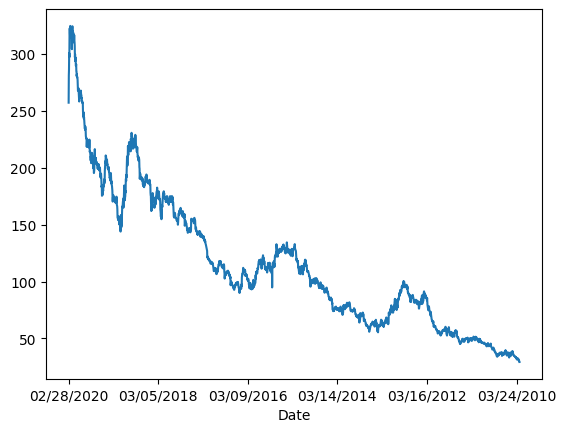

In [44]:
data["Open"].plot()

In [45]:
data.index[:5]

Index(['02/28/2020', '02/27/2020', '02/26/2020', '02/25/2020', '02/24/2020'], dtype='object', name='Date')

We can use the DatetimeIndex function to transform it into date:

In [47]:
pd.DatetimeIndex(data.index)

DatetimeIndex(['2020-02-28', '2020-02-27', '2020-02-26', '2020-02-25',
               '2020-02-24', '2020-02-21', '2020-02-20', '2020-02-19',
               '2020-02-18', '2020-02-14',
               ...
               '2010-03-12', '2010-03-11', '2010-03-10', '2010-03-09',
               '2010-03-08', '2010-03-05', '2010-03-04', '2010-03-03',
               '2010-03-02', '2010-03-01'],
              dtype='datetime64[ns]', name='Date', length=2518, freq=None)

And we can set it as the index:

In [47]:
data.index = pd.DatetimeIndex(data.index)
data

,Close,Volume,Open,High,Low
Date,,,,,
2020-02-28,273.3600,106721200,257.2600,278.4100,256.3700
2020-02-27,273.5200,80151380,281.1000,286.0000,272.9600
2020-02-26,292.6500,49678430,286.5300,297.8800,286.5000
2020-02-25,288.0800,57668360,300.9500,302.5300,286.1300
2020-02-24,298.1800,55548830,297.2600,304.1800,289.2300
...,...,...,...,...,...
2010-03-05,31.2786,224647427,30.7057,31.3857,30.6614
2010-03-04,30.1014,89591907,29.8971,30.1314,29.8043
2010-03-03,29.9043,92846488,29.8486,29.9814,29.7057


Now we can see the benefit from plotting:

<Axes: xlabel='Date'>

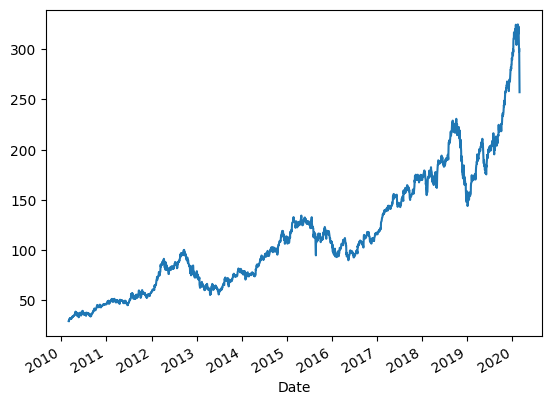

In [69]:
data["Open"].plot()

In [48]:
data.to_csv("data/HistoricalQuotes_clean.csv")

## Date Ranges

If we're entering time series data into a DataFrame, it will often be useful to create a range of dates using date_range. We can create it with different frequencies by specifying freq. Here are the days in a specific range:

In [70]:
pd.date_range(start="1/8/2022", end="3/2/2022", freq="D")

DatetimeIndex(['2022-01-08', '2022-01-09', '2022-01-10', '2022-01-11',
               '2022-01-12', '2022-01-13', '2022-01-14', '2022-01-15',
               '2022-01-16', '2022-01-17', '2022-01-18', '2022-01-19',
               '2022-01-20', '2022-01-21', '2022-01-22', '2022-01-23',
               '2022-01-24', '2022-01-25', '2022-01-26', '2022-01-27',
               '2022-01-28', '2022-01-29', '2022-01-30', '2022-01-31',
               '2022-02-01', '2022-02-02', '2022-02-03', '2022-02-04',
               '2022-02-05', '2022-02-06', '2022-02-07', '2022-02-08',
               '2022-02-09', '2022-02-10', '2022-02-11', '2022-02-12',
               '2022-02-13', '2022-02-14', '2022-02-15', '2022-02-16',
               '2022-02-17', '2022-02-18', '2022-02-19', '2022-02-20',
               '2022-02-21', '2022-02-22', '2022-02-23', '2022-02-24',
               '2022-02-25', '2022-02-26', '2022-02-27', '2022-02-28',
               '2022-03-01', '2022-03-02'],
              dtype='datetime64[n

Here are the business dates for a specific range:

In [71]:
pd.date_range(start="1/8/2022", end="3/2/2022", freq="B")

DatetimeIndex(['2022-01-10', '2022-01-11', '2022-01-12', '2022-01-13',
               '2022-01-14', '2022-01-17', '2022-01-18', '2022-01-19',
               '2022-01-20', '2022-01-21', '2022-01-24', '2022-01-25',
               '2022-01-26', '2022-01-27', '2022-01-28', '2022-01-31',
               '2022-02-01', '2022-02-02', '2022-02-03', '2022-02-04',
               '2022-02-07', '2022-02-08', '2022-02-09', '2022-02-10',
               '2022-02-11', '2022-02-14', '2022-02-15', '2022-02-16',
               '2022-02-17', '2022-02-18', '2022-02-21', '2022-02-22',
               '2022-02-23', '2022-02-24', '2022-02-25', '2022-02-28',
               '2022-03-01', '2022-03-02'],
              dtype='datetime64[ns]', freq='B')

# Summary Statistics

## Working with Summary Statistics



To calculate summary statistics in pandas, use the describe method. We can generate summary statistics for the colombia-real-estate-1 dataset with code that looks like this:

In [ ]:
import pandas as pd

df = pd.read_csv("./data/HistoricalQuotes_clean.csv")
df.describe()

,Close,Volume,Open,High,Low
count,2518.000000,2.518000e+03,2518.000000,2518.000000,2518.000000
mean,114.769522,7.258009e+07,114.728443,115.766415,113.690582
std,60.662405,5.663113e+07,60.546893,61.134456,60.085105
min,29.835700,1.136205e+07,29.392800,29.928600,28.464300
25%,66.822475,3.053026e+07,66.877150,67.475300,66.372950
50%,101.090000,5.295469e+07,101.115000,102.085000,100.350000
75%,154.630000,9.861006e+07,154.610000,155.735000,153.325000
max,327.200000,4.624423e+08,324.740000,327.850000,323.350000


By default, the describe method will return count, mean, standard deviations, minimum valuesand maximum values. Also by default, the ignores ignores non-numerical columns.

# Calculate the Quantiles for a Series

In [ ]:
df.Close.quantile(0.5)

np.float64(101.09)

## Quartiles



A commonly used set of quantiles are the fourth quantiles known as quartiles. You can also find the minimum, first quartile, median, third quartile and maximum values in a series (which are typically the values used to create a boxplot):

In [ ]:
df.Close.quantile([0, 0.25, 0.5, 0.75, 1])

0.00     29.835700
0.25     66.822475
0.50    101.090000
0.75    154.630000
1.00    327.200000
Name: Close, dtype: float64

# Correlations

In [ ]:
close= df["Close"]
vol = df["Volume"]
correlation = close.corr(vol)
print(correlation)

-0.6085020629094002
